# Kronos K-line Tokenizer

## Purpose

Kronos converts a continuous financial K-line sequence into a sequence of discrete representations. Each one-minute bar is represented by two categorical IDs:

- **`s1` — coarse subtoken:** intended to capture the principal structure of the K-line state;
- **`s2` — fine subtoken:** intended to encode residual information that refines the coarse representation.

Each ID lies in:

$$
\{0,\ldots,1023\}.
$$

The pair $(s1,s2)$ therefore represents a 20-bit discrete state. The integer IDs are categorical labels: token `625` is not inherently one unit larger than, or more similar to, token `624`.

The tokenizer is distinct from the Kronos forecasting model. The tokenizer performs:

$$
\text{continuous OHLCV}
\rightarrow
\text{discrete }(s1,s2)
\rightarrow
\text{reconstructed OHLCV}.
$$

The Kronos forecaster instead learns probability distributions over future token IDs.

---

## 1. Input construction

For one asset and one context window, the project supplies:

$$
X\in\mathbb{R}^{T\times 5},
$$

with channel order:

$$
[\text{Open},\text{High},\text{Low},\text{Close},\text{Volume}].
$$

In this project:

$$
T=60.
$$

Kronos expects six OHLCVA channels, so an all-zero Amount channel is appended:

$$
X^{(6)}
=
[\text{Open},\text{High},\text{Low},\text{Close},
\text{Volume},\text{Amount}=0].
$$

Each asset is tokenized independently. For a batch containing $B$ windows and $N$ assets, the project tensor

$$
[B,T,N,5]
$$

is internally rearranged into:

$$
[B\times N,T,6].
$$

---

## 2. Context normalisation

Kronos normalises each asset-window and each channel independently over the supplied time dimension.

For channel $c$:

$$
\mu_c
=
\frac{1}{T}
\sum_{t=1}^{T}X_{t,c},
$$

$$
\sigma_c
=
\sqrt{
\frac{1}{T}
\sum_{t=1}^{T}
(X_{t,c}-\mu_c)^2
},
$$

and:

$$
Z_{t,c}
=
\operatorname{clip}
\left(
\frac{X_{t,c}-\mu_c}
{\sigma_c+\epsilon},
-5,
5
\right),
$$

where:

$$
\epsilon=10^{-5}.
$$

Only the bars inside the supplied context are used to calculate $\mu_c$ and $\sigma_c$. The mean and standard deviation are retained because they are required to transform decoded values back into their original price and volume scales.

The tokenizer therefore primarily represents the shape and relative movements within a context, rather than having to encode the absolute price level directly.

---

## 3. Causal Transformer encoder

The normalised sequence is passed through the frozen Kronos tokenizer encoder:

$$
\xi_t
=
E_{\mathrm{enc}}(Z_{\leq t}).
$$

The encoder uses causal self-attention, so the latent representation at time $t$ can use:

$$
Z_1,\ldots,Z_t,
$$

but not any future observations.

Consequently, although Kronos produces one token pair per bar, the token at time $t$ is **contextual**. It represents the current K-line in the context of the preceding sequence; it is not merely a pointwise quantisation of the six values at that bar.

---

## 4. Binary Spherical Quantisation

The continuous encoder representation is discretised using **Binary Spherical Quantisation (BSQ)**.

Conceptually, BSQ:

1. maps the continuous latent representation onto a hyperspherical latent space;
2. quantises each latent component according to its sign;
3. produces a binary vector whose elements lie in:

$$
\{-1,+1\}.
$$

Kronos uses a 20-bit code:

$$
b_t\in\{-1,+1\}^{20}.
$$

This defines an implicit vocabulary of:

$$
2^{20}=1{,}048{,}576
$$

possible complete codes, without requiring a conventional learned lookup table containing more than one million code vectors.

The 20-bit code is divided equally into two components:

$$
b_t=[b_t^c,b_t^f],
$$

where:

$$
b_t^c\in\{-1,+1\}^{10},
\qquad
b_t^f\in\{-1,+1\}^{10}.
$$

The corresponding integer IDs are:

$$
s1_t\in\{0,\ldots,1023\},
\qquad
s2_t\in\{0,\ldots,1023\}.
$$

The IDs are compact integer representations of the underlying 10-bit patterns. The complete representation at each bar is therefore:

$$
[s1_t,s2_t].
$$

---

## 5. Coarse-to-fine hierarchy

The tokenizer is trained with two reconstruction objectives.

### Coarse reconstruction

The decoder receives only the coarse code:

$$
\widehat Z_t^{\,c}
=
D_c(b_t^c).
$$

The corresponding objective encourages `s1` to retain enough information to produce a lower-fidelity reconstruction:

$$
\mathcal L_{\mathrm{coarse}}
=
\mathbb E
\left[
\left\|
Z-\widehat Z^{\,c}
\right\|^2
\right].
$$

### Full reconstruction

The decoder receives both the coarse and fine codes:

$$
\widehat Z_t^{\,f}
=
D([b_t^c,b_t^f]).
$$

The full reconstruction loss is:

$$
\mathcal L_{\mathrm{fine}}
=
\mathbb E
\left[
\left\|
Z-\widehat Z^{\,f}
\right\|^2
\right].
$$

The complete tokenizer objective also contains a BSQ quantisation loss:

$$
\mathcal L_{\mathrm{tokenizer}}
=
\mathcal L_{\mathrm{coarse}}
+
\mathcal L_{\mathrm{fine}}
+
\lambda\mathcal L_{\mathrm{quant}}.
$$

This objective is intended to make:

- `s1` encode the principal structure of the observation;
- `s2` encode additional residual detail needed to improve reconstruction.

The fine stream is therefore a refinement of the coarse representation rather than a completely independent representation.

---

## 6. Decoding back to the original data space

The stored token IDs are first converted back into their bipolar bit vectors. The frozen Transformer decoder then reconstructs the normalised OHLCVA sequence.

For the full reconstruction:

$$
(s1,s2)
\rightarrow
[b^c,b^f]
\rightarrow
\widehat Z.
$$

For the coarse reconstruction:

$$
s1
\rightarrow
b^c
\rightarrow
\widehat Z^{\,c}.
$$

The normalisation is then inverted:

$$
\widehat X_{t,c}
=
\widehat Z_{t,c}
(\sigma_c+\epsilon)
+
\mu_c.
$$

The reconstructed Amount channel is discarded, leaving:

$$
[\widehat O,\widehat H,\widehat L,\widehat C,\widehat V].
$$

Because BSQ is lossy, the reconstructed values need not exactly equal the original values. The reconstruction analysis in this notebook measures how much information is lost.

---

## 7. Rolling causal tokenisation used in this notebook

The analysis does not tokenize an entire trading day once. Instead, every eligible bar receives its own causal 60-minute context.

For bar $t$:

$$
\text{context}_t
=
[X_{t-59},\ldots,X_t].
$$

That context is independently normalised and tokenized, and only the final token pair is retained:

$$
(s1_t,s2_t)
=
\operatorname{Tokenizer}
(\text{context}_t)_{\mathrm{final}}.
$$

The decoder similarly reconstructs the full context, after which only its final reconstructed bar is retained.

For a 390-bar trading session:

- bars $0,\ldots,58$ are invalid because they lack 60 observations of history;
- bars $59,\ldots,389$ each have one causal token pair and one reconstructed value;
- there are 331 valid tokenized bars per session.

The cached daily tensors therefore have the layouts:

$$
s1,s2:
[\text{session},\text{bar},\text{asset}],
$$

and:

$$
\widehat X:
[\text{session},\text{bar},\text{asset},\text{channel}].
$$

Each reconstructed point is the final-point reconstruction from its own trailing context. It is not a single free-running reconstruction of the complete trading day.

---

## 8. Questions addressed by this notebook

The tokenizer evaluation is divided into three questions:

1. **Reconstruction fidelity**  
   How closely do the coarse and full reconstructions reproduce the original prices, returns, volume and candle structure?

2. **Codebook utilisation**  
   How broadly and evenly are the available coarse and fine IDs used?

3. **Token predictability and dependence**  
   How much does the current token reduce uncertainty about future tokens, and how much cross-asset dependence is present in the discrete representation?

A tokenizer is useful for the final model only if it both:

- retains the financially relevant information in the continuous input; and
- produces a discrete sequence with exploitable temporal or cross-asset structure.

In [5]:
from pathlib import Path
import sys

# Make sure notebook can import from src/.
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

from src.data.load_candle_data import (
    clean_candle_splits,
    load_candle_splits,
)
from src.evaluation.tokenizer_metrics import (
    compute_codebook_usage_metrics,
    compute_cross_asset_mi_analysis,
    compute_invalid_candle_metrics,
    compute_reconstruction_metrics,
    compute_s1_topk_locf_reconstruction_sweep,
    compute_token_predictability_table,
    load_tokenizer_analysis_periods,
    plot_cross_asset_mi_heatmap,
    plot_cross_asset_mi_regime_heatmaps,
    plot_tokenizer_reconstruction,
    style_s1_topk_locf_reconstruction_table,
)
from src.utils.config import load_yaml


Project root: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis


## Configuration

This notebook is analysis-only. It does not create another permanent
`encoded_kronos_train/test` or `decoded_kronos_train/test` cache.

It loads the canonical rolling caches:

- `encoded_data.pt` and `decoded_data.pt` for January–August;
- `encoded_data_val.pt` and `decoded_data_val.pt` for September;

and constructs the January–June training view and July–September evaluation
view in memory by session date.

The temporary remapping directory is retained because it contains the
already-generated top-\(K\) reconstruction variants.

In [6]:
CONTEXT_LENGTH = 60
WINDOW_BATCH_SIZE = 8
SERIES_BATCH_SIZE = 93

DATA_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "Shared drives/Vishal/data/cached_datasets/"
    "exp-1m-95s-24y/session"
)

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "forecasting.yaml"
)

TOKEN_CACHE_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/final_model/tokens"
)

# Canonical full rolling-token and reconstruction caches.
ENCODED_MAIN_PATH = (
    TOKEN_CACHE_DIR
    / "encoded_data.pt"
)
ENCODED_VALIDATION_PATH = (
    TOKEN_CACHE_DIR
    / "encoded_data_val.pt"
)
DECODED_MAIN_PATH = (
    TOKEN_CACHE_DIR
    / "decoded_data.pt"
)
DECODED_VALIDATION_PATH = (
    TOKEN_CACHE_DIR
    / "decoded_data_val.pt"
)

# Existing exploratory top-k encoded/decoded reconstruction variants.
REMAP_TEMP_DIR = (
    TOKEN_CACHE_DIR
    / "tmp_s1_topk_global_history_locf_validation"
)

for required_path in (
    DATA_DIR,
    CONFIG_PATH,
    ENCODED_MAIN_PATH,
    ENCODED_VALIDATION_PATH,
    DECODED_MAIN_PATH,
    DECODED_VALIDATION_PATH,
):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

print("Token cache directory:", TOKEN_CACHE_DIR)


Token cache directory: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/final_model/tokens


## Load canonical data and create the analysis periods

The raw candle splits are still loaded because reconstruction and volatility
metrics require the original OHLCV values.

The token and decoded caches are not regenerated. The canonical January–August
and September files are sliced and combined in memory into:

- **tokenizer training:** January–June;
- **tokenizer validation:** July–September.

Date, asset-order, valid-mask, context-length and tokenizer-revision checks are
performed before any metric is calculated.

In [7]:
config = load_yaml(CONFIG_PATH)

train_raw, val_raw, test_raw = load_candle_splits(
    DATA_DIR
)

train, val, test = clean_candle_splits(
    train_raw,
    val_raw,
    test_raw,
)

analysis_periods = load_tokenizer_analysis_periods(
    reference_split=train,
    candle_source_splits=(
        train,
        val,
    ),
    encoded_cache_paths=(
        ENCODED_MAIN_PATH,
        ENCODED_VALIDATION_PATH,
    ),
    decoded_cache_paths=(
        DECODED_MAIN_PATH,
        DECODED_VALIDATION_PATH,
    ),
    training_start="2024-01-01",
    training_end="2024-07-01",
    validation_start="2024-07-01",
    validation_end="2024-10-01",
)

kronos_train = analysis_periods.train_split
kronos_val = analysis_periods.validation_split
encoded_kronos_train = analysis_periods.train_encoded
encoded_kronos_val = analysis_periods.validation_encoded
decoded_kronos_val = analysis_periods.validation_decoded

if int(encoded_kronos_train["context_length"]) != CONTEXT_LENGTH:
    raise RuntimeError(
        "Training cache context length does not match CONTEXT_LENGTH."
    )

if int(encoded_kronos_val["context_length"]) != CONTEXT_LENGTH:
    raise RuntimeError(
        "Validation cache context length does not match CONTEXT_LENGTH."
    )

print(
    "Tokenizer training period:",
    encoded_kronos_train["dates"][0],
    "to",
    encoded_kronos_train["dates"][-1],
    f"({len(encoded_kronos_train['dates'])} sessions)",
)
print(
    "Tokenizer validation period:",
    encoded_kronos_val["dates"][0],
    "to",
    encoded_kronos_val["dates"][-1],
    f"({len(encoded_kronos_val['dates'])} sessions)",
)
print(
    "Rolling context shape:",
    tuple(encoded_kronos_val["context_s1"].shape),
)


Tokenizer training period: 2024-01-02 to 2024-06-28 (124 sessions)
Tokenizer validation period: 2024-07-01 to 2024-09-30 (63 sessions)
Rolling context shape: (63, 331, 60, 93)


# Plot actual vs decoded

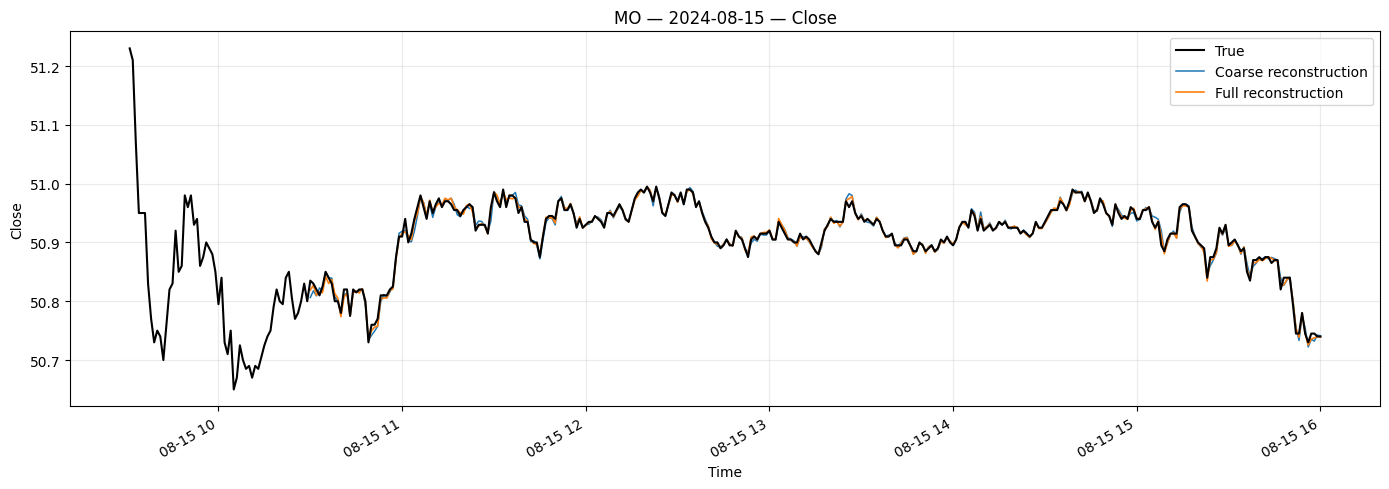

{'session_idx': 31,
 'date': Timestamp('2024-08-15 00:00:00'),
 'asset': 'MO',
 'asset_idx': 52,
 'channel': 'close',
 'reconstruction': 'both',
 'first_valid_bar': 59,
 'last_valid_bar': 389}

In [8]:
figure, axis, selection = (
    plot_tokenizer_reconstruction(
        kronos_val,
        decoded_kronos_val,
        channel="close",
    )
)

selection

# Compute the reconstruction metrics

In [9]:
reconstruction_metrics = (
    compute_reconstruction_metrics(
        kronos_val,
        encoded_kronos_val,
        decoded_kronos_val,
    )
)

display(reconstruction_metrics)

,Close Median Error (bps),Close P95 Error (bps),Return MAE (bps),Return Correlation,Return Volatility Ratio,Log-Volume MAE,Invalid Candles (%)
Reconstruction,,,,,,,
Rolling Mean,11.876876,43.729928,3.653667,0.119840,0.134003,0.793920,0.000000
Coarse (s1),0.896287,3.756897,1.660665,0.878756,0.972224,0.263228,11.110286
Full (s1 + s2),0.725043,2.919023,1.327114,0.926087,0.973377,0.230471,12.468024


## Reconstruction fidelity

### Objective

This section measures how much information is lost when the **true Kronos representations** are passed through the frozen decoder.

The evaluation path is:

$$
\text{observed OHLCV}
\rightarrow
\text{true Kronos representation}
\rightarrow
\text{decoded OHLCV}.
$$

There is no forecasting error in this experiment: the decoder is given the representation produced by the encoder for the observed data. The results therefore measure **tokenisation and reconstruction distortion**, not future-token predictability.

Two reconstruction modes are compared:

- **Coarse (`s1`)**: reconstruction using only the 10-bit coarse representation;
- **Full (`s1+s2`)**: reconstruction using both the 10-bit coarse and 10-bit fine representations.

The comparison between these rows measures the incremental contribution of the fine representation `s2`.

Each eligible minute is reconstructed from its own trailing 60-minute causal context. Metrics are calculated over the July–September 2024 evaluation period, using only bars with a complete context.

---

### Notation and aggregation

Let:

- $d$ index trading sessions;
- $t$ index valid intraday bars;
- $a$ index assets;
- $C_{d,t,a}$ and $\widehat C_{d,t,a}$ denote the true and reconstructed Close;
- $V_{d,t,a}$ and $\widehat V_{d,t,a}$ denote the true and reconstructed Volume.

Except for the invalid-candle rate, each metric is calculated separately for every asset and then summarised using the median across the 93 assets:

$$
\text{Reported metric}
=
\operatorname{median}_{a}
\left(
\text{metric for asset }a
\right).
$$

This prevents assets with higher prices, volatility or volume from dominating the aggregate result.

One basis point is:

$$
1\text{ bp}=0.01\%.
$$

---

## Metric definitions

### 1. Close Median Error (bps)

For every valid observation, the absolute Close reconstruction error is calculated in basis points:

$$
e^{C}_{d,t,a}
=
10{,}000
\left|
\log
\left(
\frac{\widehat C_{d,t,a}}
{C_{d,t,a}}
\right)
\right|.
$$

For each asset, the median is taken across all valid observations:

$$
E^{C,\mathrm{median}}_a
=
\operatorname{median}_{d,t}
\left(
e^{C}_{d,t,a}
\right).
$$

The table reports:

$$
\operatorname{median}_a
\left(
E^{C,\mathrm{median}}_a
\right).
$$

**Interpretation:** this is the typical relative Close-price reconstruction error for the median asset. Lower is better, and zero represents exact reconstruction.

---

### 2. Close P95 Error (bps)

Using the same pointwise Close error $e^C_{d,t,a}$, the 95th percentile is calculated separately for each asset:

$$
E^{C,95}_a
=
Q_{0.95}
\left(
e^C_{d,t,a}
\right).
$$

The table reports:

$$
\operatorname{median}_a
\left(
E^{C,95}_a
\right).
$$

**Interpretation:** this measures reconstruction quality in the more difficult tail of observations. For the median asset, 95% of reconstructed Close values have an error below this number. Lower is better.

---

### 3. Return MAE (bps)

True and reconstructed one-minute log returns are calculated from consecutive valid Close values within the same trading session:

$$
r_{d,t,a}
=
\log
\left(
\frac{C_{d,t,a}}
{C_{d,t-1,a}}
\right),
$$

$$
\widehat r_{d,t,a}
=
\log
\left(
\frac{\widehat C_{d,t,a}}
{\widehat C_{d,t-1,a}}
\right).
$$

No return is calculated across an overnight session boundary.

The return reconstruction error is:

$$
e^r_{d,t,a}
=
10{,}000
\left|
\widehat r_{d,t,a}
-
r_{d,t,a}
\right|.
$$

For each asset, this error is averaged over all valid returns:

$$
E^r_a
=
\operatorname{mean}_{d,t}
\left(
e^r_{d,t,a}
\right).
$$

The table reports the median $E^r_a$ across assets.

**Interpretation:** this is the average distortion introduced into the one-minute return series, measured in basis points. Lower is better. It is more demanding than price-level reconstruction because small Close errors at consecutive minutes can alter the reconstructed return.

---

### 4. Return Correlation

For each asset, Pearson correlation is calculated between its complete true and reconstructed one-minute return series:

$$
\rho_a
=
\operatorname{Corr}
\left(
\{\widehat r_{d,t,a}\}_{d,t},
\{r_{d,t,a}\}_{d,t}
\right).
$$

The table reports:

$$
\operatorname{median}_a(\rho_a).
$$

**Interpretation:**

- $\rho=1$: the reconstructed return path moves exactly with the true path;
- $\rho=0$: no linear alignment between reconstructed and true returns;
- $\rho<0$: reconstructed returns tend to move in the opposite direction.

Higher is better. Unlike the price-level errors, this metric asks whether the reconstruction preserves the actual pattern of minute-to-minute movements.

---

### 5. Return Volatility Ratio

For each asset, the standard deviation of reconstructed returns is divided by the standard deviation of true returns:

$$
R^{\mathrm{vol}}_a
=
\frac{
\operatorname{Std}(\widehat r_{d,t,a})
}{
\operatorname{Std}(r_{d,t,a})
}.
$$

The table reports:

$$
\operatorname{median}_a
\left(
R^{\mathrm{vol}}_a
\right).
$$

**Interpretation:**

- $R^{\mathrm{vol}}=1$: the reconstructed return series has the correct dispersion;
- $R^{\mathrm{vol}}<1$: the decoder smooths return movements;
- $R^{\mathrm{vol}}>1$: the decoder exaggerates return movements.

The desired value is one, rather than simply a larger or smaller value.

---

### 6. Log-Volume MAE

Because raw trading volume differs substantially across assets and market conditions, Volume is compared after a $\log(1+x)$ transformation:

$$
e^V_{d,t,a}
=
\left|
\log
\left(
1+\max(\widehat V_{d,t,a},0)
\right)
-
\log
\left(
1+V_{d,t,a}
\right)
\right|.
$$

For each asset:

$$
E^V_a
=
\operatorname{mean}_{d,t}
\left(
e^V_{d,t,a}
\right),
$$

and the table reports the median $E^V_a$ across assets.

Negative reconstructed Volume is set to zero for this error calculation, but it is still counted as an invalid candle by the structural-validity metric.

**Interpretation:** lower values indicate that the decoder better preserves the scale of trading activity. The value is in log-volume units and should primarily be interpreted comparatively between coarse and full reconstruction.

---

### 7. Invalid Candles (%)

A reconstructed candle is marked invalid if any of the following holds:

$$
\widehat O\leq0,\quad
\widehat H\leq0,\quad
\widehat L\leq0,\quad
\widehat C\leq0,
$$

$$
\widehat H
<
\max(\widehat O,\widehat C),
$$

$$
\widehat L
>
\min(\widehat O,\widehat C),
$$

$$
\widehat H<\widehat L,
$$

$$
\widehat V<0,
$$

or any reconstructed channel is non-finite.

The reported rate is pooled over all valid sessions, bars and assets:

$$
\text{Invalid Rate}
=
100
\times
\frac{
\sum_{d,t,a}
\mathbf{1}
\left[
\text{candle}_{d,t,a}
\text{ is invalid}
\right]
}{
\text{number of valid reconstructed candles}
}.
$$

**Interpretation:** this measures whether decoded OHLCV values obey the structural constraints of a valid financial candle. Lower is better and zero is ideal. The metric is binary: even a very small High/Close or Low/Close crossing counts as invalid, so the rate must be interpreted alongside the magnitude and type of violations.

---

## Results

| Reconstruction | Close Median Error | Close P95 Error | Return MAE | Return Correlation | Return Volatility Ratio | Log-Volume MAE | Invalid Candles |
|---|---:|---:|---:|---:|---:|---:|---:|
| Coarse (`s1`) | 0.896 bps | 3.757 bps | 1.661 bps | 0.879 | 0.972 | 0.263 | 11.11% |
| Full (`s1+s2`) | 0.725 bps | 2.919 bps | 1.327 bps | 0.926 | 0.973 | 0.230 | 12.47% |

---

## Interpretation of the results

### Price-level reconstruction is highly accurate

The full reconstruction has a median Close error of:

$$
0.725\text{ bps}
=
0.00725\%.
$$

For the median asset, 95% of reconstructed Close observations have an error below:

$$
2.919\text{ bps}
=
0.02919\%.
$$

The decoder therefore reproduces raw Close levels with high accuracy in both typical and more difficult observations.

Adding the fine representation reduces:

- median Close error by approximately **19.1%**;
- P95 Close error by approximately **22.3%**.

This shows that `s2` provides meaningful residual information beyond the coarse `s1` representation.

---

### The full representation preserves one-minute returns substantially better

Return MAE decreases from:

$$
1.661\text{ bps}
\rightarrow
1.327\text{ bps},
$$

a reduction of approximately **20.1%**.

Return correlation rises from:

$$
0.879
\rightarrow
0.926.
$$

The coarse representation already preserves most of the return path, but the fine representation substantially improves the alignment of individual minute-to-minute movements.

The remaining return MAE is not negligible merely because the price-level plot looks visually accurate. One-minute financial returns are small, so a distortion of approximately 1.33 bps can still be material for a forecasting task.

---

### Both reconstructions preserve aggregate return volatility

The volatility ratios are:

$$
0.972
\quad\text{and}\quad
0.973.
$$

Thus, the decoded return series retain approximately 97% of the true return standard deviation for the median asset.

Both reconstructions exhibit slight smoothing, but the effect is small. The fine representation improves pointwise return accuracy and return correlation much more than it changes aggregate volatility. This suggests that `s1` already captures most of the broad movement magnitude, while `s2` helps place individual movements more accurately.

---

### The fine representation also improves Volume reconstruction

Log-Volume MAE decreases from:

$$
0.263
\rightarrow
0.230,
$$

an improvement of approximately **12.4%**.

The fine representation therefore contributes information not only to Close prices and returns, but also to trading-activity reconstruction.

---

### Candle validity is the main weakness

The invalid-candle rate is:

$$
11.11\%
$$

for the coarse reconstruction and:

$$
12.47\%
$$

for the full reconstruction.

The full representation is more accurate on every level and return metric, but produces a slightly larger number of formal candle violations. This is possible because the decoder can reconstruct each OHLC channel very accurately while still placing High fractionally below Open or Close, or Low fractionally above Open or Close.

The aggregate invalid rate does not show how large these violations are. A separate breakdown of violation type and magnitude is therefore required before deciding whether this represents a material reconstruction problem or mostly very small numerical boundary crossings.

---

## Overall conclusion

The Kronos tokenizer preserves the observed financial series with high fidelity:

- typical and tail Close errors are small;
- the reconstructed one-minute return path is strongly correlated with the original path;
- return volatility is only slightly smoothed;
- Volume reconstruction is reasonably accurate.

The coarse `s1` representation captures most of the underlying structure, while the fine `s2` representation is clearly **not redundant**: it reduces price and return errors by approximately 19–22%, increases return correlation from 0.879 to 0.926, and improves Volume reconstruction.

The main issue is structural candle validity, which must be examined through the subsequent violation breakdown. These results establish that the representation retains most of the financial information in the input. They do **not** establish that future representations are easy to forecast; next-representation predictability is evaluated separately.

In [10]:
invalid_candle_metrics = (
    compute_invalid_candle_metrics(
        kronos_val,
        decoded_kronos_val,
    )
)

display(invalid_candle_metrics)

,Any Invalid (%),High Below Body (%),Low Above Body (%),High Below Low (%),Non-positive OHLC (%),Negative Volume (%),Median Structural Violation (bps),P95 Structural Violation (bps)
Reconstruction,,,,,,,,
Coarse (s1),11.110286,6.438619,6.515140,0.417619,0.0,2.503340,0.270562,1.264348
Full (s1 + s2),12.468024,6.104947,8.147663,0.252149,0.0,2.210713,0.265471,1.228476


# Compute Codebook Usage Metrics

In [11]:
codebook_usage_metrics = (
    compute_codebook_usage_metrics(
        encoded_kronos_train,
        k=200
    )
)

display(codebook_usage_metrics)

,Observations,Tokens Used,Codebook Usage (%),Entropy (bits),Normalised Entropy,Effective Vocabulary,Most Common Token (%),Top-200 Token Share (%)
Token Stream,,,,,,,,
Coarse (s1),3817092,751,73.339844,6.950850,0.695085,123.712746,4.280379,97.701339
Fine (s2),3817092,484,47.265625,5.125591,0.512559,34.910556,13.663228,99.926882


## Codebook utilisation

### Objective

Each Kronos subtoken has its own codebook containing:

$$
V=2^{10}=1024
$$

possible IDs.

This section examines how broadly and evenly those IDs are used by the July–September 2024 evaluation data.

The two streams are analysed separately:

- **Coarse (`s1`)**: the 10-bit coarse representation;
- **Fine (`s2`)**: the 10-bit fine representation.

This analysis is **marginal**: it studies the overall frequency distribution of each stream without conditioning on previous representations, assets, or market states.

It therefore answers:

> How much of each codebook is used, and how concentrated is the probability mass among the used IDs?

It does **not** yet answer:

- how predictable the next representation is;
- how `s1` and `s2` depend on one another;
- how much additional information `s2` provides conditional on `s1`;
- what financial meaning any individual ID has.

Those questions require separate conditional or semantic analyses.

---

## Observations included

Only positions marked valid by the rolling 60-minute tokenisation procedure are included.

The evaluation period contains:

- 63 trading sessions;
- 331 valid bars per session;
- 93 assets.

Therefore, the number of valid observations in each stream is:

$$
M
=
63
\times
331
\times
93
=
1{,}939{,}329.
$$

Each valid asset-minute produces exactly one `s1` ID and one `s2` ID, so both streams contain the same number of observations.

Unlike the reconstruction metrics, the codebook metrics are not first calculated per asset. All valid observations are pooled into one empirical frequency distribution for each stream.

---

## Notation

For a given stream, let:

- $n_k$ be the number of times codebook ID $k$ occurs;
- $M$ be the total number of valid observations;
- $p_k$ be the empirical probability of ID $k$.

Thus:

$$
p_k
=
\frac{n_k}{M},
\qquad
k\in\{0,\ldots,1023\}.
$$

The probabilities satisfy:

$$
\sum_{k=0}^{1023}p_k=1.
$$

---

## Metric definitions

### 1. Observations

This is the total number of valid representation IDs analysed:

$$
M
=
\sum_{k=0}^{V-1}n_k.
$$

**Interpretation:** this describes the sample size used to estimate the codebook distribution. It is not a measure of representation quality.

---

### 2. Tokens Used

The number of codebook IDs that occur at least once is:

$$
U
=
\sum_{k=0}^{V-1}
\mathbf{1}[n_k>0].
$$

**Interpretation:** this measures codebook coverage. A value of 711 means that 711 of the 1,024 possible IDs appeared at least once.

This metric does not account for frequency. An ID appearing once and an ID appearing one million times both count equally as “used.”

---

### 3. Codebook Usage (%)

Codebook usage is the proportion of available IDs observed at least once:

$$
\text{Usage}
=
100
\times
\frac{U}{V}.
$$

Because:

$$
V=1024,
$$

a usage value of 69.4% means that approximately 69.4% of the available IDs occurred in the evaluation data.

**Interpretation:**

- high usage indicates that many different states are represented;
- very low usage may indicate codebook collapse or a codebook poorly matched to the data;
- high usage alone does not imply balanced use, because many IDs may occur only rarely.

---

### 4. Entropy (bits)

The empirical Shannon entropy of a stream is:

$$
H(S)
=
-\sum_{k:p_k>0}
p_k\log_2p_k.
$$

The maximum possible entropy occurs when all 1,024 IDs are equally likely:

$$
H_{\max}
=
\log_2(1024)
=
10\text{ bits}.
$$

**Interpretation:** entropy measures the average uncertainty in the representation before observing any context.

- high entropy means probability mass is distributed across many IDs;
- low entropy means observations are concentrated in a smaller set of common IDs;
- entropy is maximised only when all IDs are equally likely.

High entropy is not automatically good, and low entropy is not automatically bad. A useful representation may have a non-uniform distribution because some market states are much more common than others.

This is **marginal entropy**, not next-representation predictability. Predictability depends on conditional entropy, such as:

$$
H(S_{t+h}\mid S_t).
$$

---

### 5. Normalised Entropy

Entropy is divided by its maximum possible value:

$$
H_{\mathrm{norm}}
=
\frac{H(S)}
{\log_2V}.
$$

Since $V=1024$:

$$
H_{\mathrm{norm}}
=
\frac{H(S)}{10}.
$$

The result lies between zero and one.

**Interpretation:**

- $H_{\mathrm{norm}}=1$: all 1,024 IDs are used uniformly;
- $H_{\mathrm{norm}}=0$: every observation has the same ID.

Normalised entropy is not the same as codebook usage. A stream may use many IDs but still have low normalised entropy if most probability mass is concentrated in a small subset.

---

### 6. Effective Vocabulary

The entropy is converted into an entropy-equivalent vocabulary size:

$$
V_{\mathrm{eff}}
=
2^{H(S)}.
$$

This is the size of a hypothetical uniformly distributed vocabulary with the same entropy as the observed distribution.

For example, if:

$$
H(S)=5,
$$

then:

$$
V_{\mathrm{eff}}=2^5=32.
$$

**Interpretation:** an effective vocabulary of 122 does **not** mean that only 122 IDs occurred. It means that the observed, non-uniform distribution has the same entropy as a uniform distribution over approximately 122 states.

The difference between `Tokens Used` and `Effective Vocabulary` reveals how long-tailed the distribution is:

- `Tokens Used` counts every ID that occurs at least once;
- `Effective Vocabulary` discounts IDs that occur only rarely.

---

### 7. Most Common Token (%)

Let:

$$
p_{\max}
=
\max_k p_k.
$$

The reported metric is:

$$
100p_{\max}.
$$

**Interpretation:** this is the share of observations assigned to the single most frequent ID. A large value indicates that one state dominates the stream.

---

### 8. Top-10 Token Share (%)

Let $\mathcal T_{10}$ be the set of ten most frequently observed IDs. The metric is:

$$
100
\sum_{k\in\mathcal T_{10}}
p_k.
$$

**Interpretation:** this measures how much of the complete stream is represented by only ten IDs.

- a low value indicates broad distribution across the codebook;
- a high value indicates strong concentration in a small set of common states.

---

## Results

| Token stream | Observations | Tokens used | Codebook usage | Entropy | Normalised entropy | Effective vocabulary | Most common ID | Top-10 share |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Coarse (`s1`) | 1,939,329 | 711 | 69.43% | 6.929 bits | 0.693 | 121.85 | 4.59% | 26.54% |
| Fine (`s2`) | 1,939,329 | 457 | 44.63% | 5.103 bits | 0.510 | 34.36 | 13.89% | 62.31% |

---

## Interpretation of the results

### The coarse stream uses a broad codebook

The coarse stream uses:

$$
711
$$

of the 1,024 available IDs, corresponding to:

$$
69.43\%
$$

codebook coverage.

Its entropy is:

$$
H(s1)=6.929\text{ bits},
$$

which corresponds to an effective vocabulary of:

$$
2^{6.929}
\approx121.85.
$$

Thus, although 711 coarse IDs appear at least once, the frequency distribution has the same entropy as a uniform vocabulary of approximately 122 states.

This indicates a long-tailed distribution:

- a substantial number of IDs are used;
- many of those IDs are rare;
- the frequently occurring probability mass is distributed over a much smaller subset.

The most common coarse ID accounts for only:

$$
4.59\%
$$

of observations, and the ten most common IDs together account for:

$$
26.54\%.
$$

No individual coarse state dominates the representation. The coarse stream therefore appears broad and expressive rather than collapsed into a handful of IDs.

---

### The fine stream is much more concentrated

The fine stream uses:

$$
457
$$

IDs, or:

$$
44.63\%
$$

of its codebook.

Its entropy is:

$$
H(s2)=5.103\text{ bits},
$$

corresponding to an effective vocabulary of only:

$$
2^{5.103}
\approx34.36.
$$

The single most common fine ID accounts for:

$$
13.89\%
$$

of all observations, while the ten most common IDs account for:

$$
62.31\%.
$$

The fine stream is therefore substantially more concentrated than the coarse stream:

- fewer IDs are observed;
- the effective vocabulary is much smaller;
- a small set of common IDs explains most observations.

The coarse stream has approximately:

$$
\frac{121.85}{34.36}
\approx3.55
$$

times the effective vocabulary of the fine stream.

---

### Lower fine-stream utilisation does not imply that `s2` is redundant

The fine representation is designed to refine the coarse representation rather than independently encode the complete K-line state.

A concentrated fine distribution is therefore plausible: many observations may require one of a small number of common corrections, while a larger number of rare fine states represent less common residual patterns.

Most importantly, the reconstruction analysis shows that adding `s2`:

- reduces median Close error by approximately 19%;
- reduces P95 Close error by approximately 22%;
- reduces return MAE by approximately 20%;
- increases return correlation from 0.879 to 0.926;
- improves Volume reconstruction.

Therefore, the lower fine-stream entropy and usage are not evidence that the fine representation is unnecessary. `s2` is empirically concentrated but still contributes substantial reconstruction information.

However, this table does not measure the incremental information in `s2` formally. Its reported value:

$$
H(s2)=5.103
$$

is marginal entropy. The relevant quantity for incremental information would be conditional entropy:

$$
H(s2\mid s1),
$$

which is not calculated here.

---

### Comparison with the published Kronos utilisation figures

The Kronos paper reports codebook usage of approximately:

- 97.66% for the coarse codebook;
- 85.25% for the fine codebook.

The present results are lower:

- 69.43% for `s1`;
- 44.63% for `s2`.

These figures are not directly comparable.

The published values are calculated over Kronos's large and diverse pre-training corpus, whereas this notebook analyses:

- 63 trading sessions;
- 93 US equities;
- one-minute frequency;
- July–September 2024 only;
- final-position representations from rolling 60-minute contexts.

A restricted financial domain and short evaluation period will naturally encounter fewer market states than a multi-market, multi-frequency pre-training corpus.

Unused IDs in this evaluation period therefore do not necessarily indicate globally dead codebook entries. They may represent market conditions that simply did not occur in this sample.

---

## Overall conclusion

The codebook analysis shows a clear hierarchical pattern:

- `s1` uses a broad, long-tailed set of coarse market states;
- `s2` uses a smaller and much more concentrated set of fine residual states.

The coarse stream does not appear collapsed: hundreds of IDs are used, no single state dominates, and the effective vocabulary remains substantial.

The fine stream is much more concentrated, but the reconstruction results show that it remains materially useful. Its lower entropy should therefore be interpreted as a more specialised residual representation rather than immediate evidence of codebook failure.

This section characterises **representation diversity**, not predictability. The next analysis asks whether observing the current representation reduces uncertainty about future representations.

# Compute predictability metrics - Entropies

In [12]:
s1_train_predictability = (
    compute_token_predictability_table(
        encoded_kronos_train,
        encoded_kronos_val,
        token_type="s1",
        transition_source="rolling",
        show_progress=False,
        rolling_lookback=5
    )
)

display(s1_train_predictability)

,Marginal CE (bits/token),Transition CE (bits/token),Marginal PPL,Transition PPL,Bits Saved
Horizon (min),,,,,
1,6.940106,6.063589,122.794844,66.884010,0.876517
5,6.945573,6.658358,123.261062,101.010226,0.287216
15,6.959480,6.958066,124.455007,124.333060,0.001414
30,6.978907,7.094735,126.142157,136.687224,-0.115828
60,7.009382,7.179969,128.835093,145.006034,-0.170587


## Predictability of the coarse representation (`s1`)

### Objective

The reconstruction analysis showed that the Kronos representations retain the observed financial data with high fidelity. The next question is whether the resulting discrete sequence is predictable.

This section asks:

> How much does observing an asset's current coarse representation reduce uncertainty about that same asset's representation \(h\) minutes later?

The analysis is deliberately simple. It uses only the current coarse ID \(S_t\) to predict the future coarse ID \(S_{t+h}\). It does not use:

- the complete 60-minute history;
- the fine representation `s2`;
- other assets;
- price or volume values;
- a learned neural model.

It is therefore a **first-order transition baseline**, not a performance ceiling for the final forecasting architecture.

---

## Construction of the transition pairs

Let:

- \(d\) index trading sessions;
- \(t\) index intraday bars;
- \(a\) index assets;
- \(h\in\{1,5,15,30,60\}\) denote the forecast horizon;
- \(S_{d,t,a}\) denote the coarse representation ID for asset \(a\).

For each horizon, the current and future variables are:

$$
X_{d,t,a}=S_{d,t,a},
$$

$$
Y^{(h)}_{d,t,a}=S_{d,t+h,a}.
$$

A pair is included only when both positions are valid and belong to the same asset and trading session. No transition crosses an overnight boundary.

For example, the five-minute analysis uses direct pairs:

$$
S_{d,t,a}\rightarrow S_{d,t+5,a}.
$$

It does **not** repeatedly apply the one-minute transition matrix five times.

Pairs from all 93 assets are pooled to estimate one common transition distribution for each horizon. Thus, the analysis estimates the average transition structure of the shared Kronos representation rather than fitting a separate matrix for every stock.

---

## The two probability models

For every horizon, two simple probability models are compared.

### Marginal model

The marginal model ignores the current representation:

$$
q_0^{(h)}(j)
=
P(S_{t+h}=j).
$$

It predicts future IDs using only their overall frequency.

This answers:

> Without observing the current ID, how uncertain is the future ID?

---

### Transition model

The transition model conditions on the current representation:

$$
q_1^{(h)}(j\mid i)
=
P(S_{t+h}=j\mid S_t=i).
$$

Each row of the transition matrix is a probability distribution over future IDs for a particular current ID.

This answers:

> After observing the current ID, how much does the set of plausible future IDs narrow?

A useful representation should satisfy:

$$
q_1^{(h)}(S_{t+h}\mid S_t)
>
q_0^{(h)}(S_{t+h})
$$

on average for the realised future observations.

---

# Evaluation protocols

Four versions of the analysis are reported. They differ only in which observations are used to estimate the marginal and transition distributions.

## 1. Validation empirical distribution

The marginal and transition distributions are both estimated from July–September and summarised on those same July–September observations.

This produces:

- marginal entropy;
- conditional entropy;
- entropy-based perplexities;
- mutual information.

This is a **descriptive, in-sample analysis**. It asks how much temporal dependence is present within July–September, but it is not a test of predicting unseen observations.

Because the same data are used to estimate and summarise the transition matrix, the result should generally be more favourable than a genuinely out-of-sample score. The plug-in mutual-information estimate is also not bias-corrected.

---

## 2. Static training transition matrix

One transition matrix is estimated from January–June, frozen, and used to score all July–September observations.

This produces:

- marginal cross-entropy;
- transition cross-entropy;
- held-out perplexities;
- bits saved by conditioning.

This is a genuine out-of-sample test.

It asks:

> Does the first-order transition structure estimated during January–June remain useful during July–September?

Poor performance can reflect weak intrinsic dependence, distributional change, estimation error, or a combination of these factors.

---

## 3. Rolling 20-session transition matrix

For each July–September session, the transition matrix is estimated from the previous 20 completed trading sessions, approximately four trading weeks.

The current session is:

1. predicted using only earlier sessions;
2. scored in full;
3. added to the rolling history only after scoring.

This produces out-of-sample rolling cross-entropies, perplexities and bits saved.

It asks:

> How predictable are future IDs using a transition model that adapts to approximately the previous month of market behaviour?

---

## 4. Rolling five-session transition matrix

This follows the same procedure but uses only the previous five completed trading sessions, approximately one trading week.

It adapts more quickly to changing conditions but uses far fewer observations to estimate a \(1024\times1024\) transition structure.

It asks:

> Does rapid adaptation to recent market behaviour compensate for the increased estimation noise of a much shorter history?

---

# Witten–Bell backoff for out-of-sample scoring

The static training and rolling transition matrices require smoothing. Without smoothing, any unseen transition would receive probability zero and therefore infinite cross-entropy.

Let:

- $K=1024$ be the vocabulary size;
- $C(j)$ be the number of occurrences of future ID \(j\);
- $N=\sum_j C(j)$;
- $T$ be the number of distinct future IDs observed.

The smoothed marginal probability is:

$$
q_0(j)
=
\frac{
C(j)+T/K
}{
N+T
}.
$$

For a current ID \(i\), let:

- $C(i,j)$ be the count of transition $i\rightarrow j$;
- $N_i=\sum_j C(i,j)$;
- $T_i$ be the number of distinct future IDs observed after $i$.

The smoothed transition probability is:

$$
q_1(j\mid i)
=
\frac{
C(i,j)+T_iq_0(j)
}{
N_i+T_i
}.
$$

If current ID \(i\) has never been observed, the transition model backs off completely to the marginal model:

$$
q_1(j\mid i)=q_0(j).
$$

Common transition rows therefore rely mainly on their empirical counts, while sparse rows rely more strongly on overall future-ID frequencies.

---

# Metric definitions

## Marginal Entropy

In the validation empirical analysis, the marginal entropy of the future representation is:

$$
H(S_{t+h})
=
-\sum_j
\widehat p_h(j)
\log_2\widehat p_h(j).
$$

**Interpretation:** this is the uncertainty in the future ID before observing the current ID.

A value of seven bits corresponds to uncertainty equivalent to a uniform choice among:

$$
2^7=128
$$

states.

Higher marginal entropy means the future-ID distribution is more diverse. It does not, by itself, mean that the sequence is difficult to predict: predictability depends on how much the entropy falls after conditioning.

---

## Conditional Entropy

The validation empirical conditional entropy is:

$$
H(S_{t+h}\mid S_t)
=
-\sum_i
\widehat p_h(i)
\sum_j
\widehat p_h(j\mid i)
\log_2
\widehat p_h(j\mid i).
$$

**Interpretation:** this is the uncertainty remaining about the future ID after the current ID is known.

Lower conditional entropy means a sharper and more predictable empirical transition distribution.

---

## Mutual Information

For the validation empirical distribution:

$$
I(S_t;S_{t+h})
=
H(S_{t+h})
-
H(S_{t+h}\mid S_t).
$$

**Interpretation:** mutual information measures how many bits of future uncertainty are removed by observing the current ID.

For example:

$$
I(S_t;S_{t+h})=1
$$

means that observing the current ID reduces the effective uncertainty by a factor of:

$$
2^1=2.
$$

Mutual information cannot be negative in the empirical table. It describes dependence present within July–September; it is not an out-of-sample forecasting score.

---

## Marginal Cross-Entropy

For the static and rolling protocols, let \(q_{0,m}^{(h)}\) be the marginal distribution available when observation \(m\) is predicted. The marginal cross-entropy is:

$$
CE_0^{(h)}
=
-\frac{1}{M_h}
\sum_{m=1}^{M_h}
\log_2
q_{0,m}^{(h)}
\left(
Y_m^{(h)}
\right).
$$

For the static protocol, the same January–June distribution is used for every validation observation.

For a rolling protocol, the distribution changes by session because it is re-estimated from the preceding \(n\) completed sessions.

**Interpretation:** this is the average number of bits required to encode the realised future IDs when no current-ID information is used.

Lower is better.

For an individual observation:

- assigned probability $0.5$ gives a loss of one bit;
- assigned probability $0.25$ gives a loss of two bits;
- assigned probability $1/128$ gives a loss of seven bits.

---

## Transition Cross-Entropy

The transition cross-entropy is:

$$
CE_1^{(h)}
=
-\frac{1}{M_h}
\sum_{m=1}^{M_h}
\log_2
q_{1,m}^{(h)}
\left(
Y_m^{(h)}
\mid
X_m
\right).
$$

**Interpretation:** this measures how much probability the fitted transition model assigns to the realised future IDs after observing the current ID.

Lower transition cross-entropy indicates better probabilistic prediction.

---

## Perplexity

Perplexity is the exponential of entropy or cross-entropy:

$$
PPL=2^{CE}.
$$

For the validation empirical analysis:

$$
PPL_{\mathrm{marginal}}
=
2^{H(S_{t+h})},
$$

$$
PPL_{\mathrm{conditional}}
=
2^{H(S_{t+h}\mid S_t)}.
$$

For the static and rolling analyses:

$$
PPL_{\mathrm{marginal}}
=
2^{CE_0^{(h)}},
$$

$$
PPL_{\mathrm{transition}}
=
2^{CE_1^{(h)}}.
$$

**Interpretation:** perplexity converts uncertainty into an effective number of equally likely alternatives.

For example:

$$
PPL=64
$$

means that the uncertainty is equivalent to choosing among 64 equally likely IDs.

This is an equivalent uncertainty scale, not a literal statement that exactly 64 candidate IDs remain possible.

Lower is better.

---

## Bits Saved

For the out-of-sample static and rolling analyses:

$$
G_h
=
CE_0^{(h)}
-
CE_1^{(h)}.
$$

Equivalently:

$$
G_h
=
\frac{1}{M_h}
\sum_m
\log_2
\frac{
q_{1,m}^{(h)}(Y_m^{(h)}\mid X_m)
}{
q_{0,m}^{(h)}(Y_m^{(h)})
}.
$$

**Interpretation:**

- $G_h>0$: conditioning on the current ID improves prediction;
- $G_h=0$: the current ID adds no benefit over recent marginal frequencies;
- $G_h<0$: conditioning makes the probability forecast worse.

A gain of $G_h$ bits corresponds to the transition model assigning the realised future ID approximately:

$$
2^{G_h}
$$

times as much probability as the marginal model on a geometric-average basis.

For example:

$$
G_h=1
$$

means that conditioning approximately doubles the probability assigned to the realised future ID and halves the effective uncertainty.

Unlike mutual information, held-out Bits Saved can be negative because a transition relationship estimated from earlier observations may fail to generalise.

---

# Results

All results below concern the coarse `s1` stream.

## Information supplied by the current representation

| Horizon | Validation empirical MI | Static Jan–Jun Bits Saved | Rolling 20-session Bits Saved | Rolling 5-session Bits Saved |
|---:|---:|---:|---:|---:|
| 1 min | 1.128 | 1.053 | 0.987 | 0.877 |
| 5 min | 0.524 | 0.439 | 0.379 | 0.287 |
| 15 min | 0.221 | 0.138 | 0.083 | 0.001 |
| 30 min | 0.102 | 0.019 | -0.036 | -0.116 |
| 60 min | 0.059 | -0.030 | -0.088 | -0.171 |

The first column is descriptive in-sample mutual information. The final three columns are out-of-sample log-loss improvements and can therefore be negative.

---

## Remaining uncertainty after conditioning

| Horizon | Marginal PPL range across protocols | Validation Conditional PPL | Static Train Transition PPL | Rolling 20-session Transition PPL | Rolling 5-session Transition PPL |
|---:|---:|---:|---:|---:|---:|
| 1 min | 121.9–122.8 | 55.8 | 58.9 | 61.7 | 66.9 |
| 5 min | 122.4–123.3 | 85.1 | 90.4 | 94.3 | 101.0 |
| 15 min | 123.5–124.5 | 106.0 | 112.4 | 116.9 | 124.3 |
| 30 min | 125.2–126.1 | 116.7 | 123.7 | 128.7 | 136.7 |
| 60 min | 127.8–128.8 | 122.7 | 130.7 | 136.2 | 145.0 |

The marginal uncertainty is very similar across protocols. The substantive differences arise from whether conditioning on the current representation successfully reduces that uncertainty.

---

# Interpretation of the results

## Strong and stable one-minute dependence

At one minute, all four analyses show a large benefit from observing the current coarse representation.

The empirical validation distribution reduces perplexity from approximately:

$$
121.9
\rightarrow
55.8.
$$

The genuinely out-of-sample transition models reduce it to:

- 58.9 using the static January–June matrix;
- 61.7 using the previous 20 sessions;
- 66.9 using the previous five sessions.

The static transition model saves:

$$
1.053\text{ bits/token},
$$

which corresponds to an average probability improvement factor of:

$$
2^{1.053}
\approx2.07.
$$

Thus, knowledge of the current coarse representation approximately doubles the probability assigned to the realised one-minute-ahead representation.

The one-minute future state remains uncertain: a transition perplexity near 59–67 is still a difficult categorical prediction problem. Nevertheless, conditioning removes approximately half of the marginal effective uncertainty.

---

## Moderate five-minute predictability

At five minutes, conditioning remains useful but the effect is smaller.

Bits Saved falls to:

- 0.439 for the static January–June matrix;
- 0.379 for the rolling 20-session matrix;
- 0.287 for the rolling five-session matrix.

The transition perplexity remains between approximately 90 and 101, compared with a marginal perplexity around 123.

The current coarse representation therefore contains exploitable five-minute information, but much less than at one minute.

---

## Weak and estimation-sensitive 15-minute dependence

The validation empirical distribution contains:

$$
0.221\text{ bits}
$$

of 15-minute mutual information.

However, out-of-sample gains are smaller:

- static January–June: 0.138 bits;
- rolling 20 sessions: 0.083 bits;
- rolling five sessions: effectively zero.

This means that some 15-minute dependence is present within July–September, but a short rolling history cannot estimate it reliably. The relationship is weak enough that the estimation variance from a five-session \(1024\)-state transition model removes almost all predictive benefit.

---

## No useful first-order prediction at 30–60 minutes

The validation empirical analysis still detects small positive dependence:

$$
I_{30}=0.102\text{ bits},
$$

$$
I_{60}=0.059\text{ bits}.
$$

However, the held-out models provide almost no benefit:

- the static matrix saves only 0.019 bits at 30 minutes;
- the static matrix is slightly harmful at 60 minutes;
- both rolling matrices are harmful at 30 and 60 minutes.

For example, the five-session transition model increases 60-minute perplexity from:

$$
128.8
\rightarrow
145.0.
$$

This distinction is important:

> A weak statistical relationship can be present within an observed period without being stable or strong enough for a historical transition matrix to exploit out of sample.

The negative values do not imply negative mutual information. They mean that the fitted conditional model assigned lower probability to the realised future IDs than the marginal model.

---

## A shorter rolling history does not improve prediction

Across every horizon, the broad ordering is:

$$
\text{static Jan--Jun}
>
\text{rolling 20 sessions}
>
\text{rolling 5 sessions}.
$$

The five-session model adapts most quickly, but it also has the least data with which to estimate a large transition matrix.

The result suggests that, for this first-order model, the benefit of rapid adaptation is outweighed by increased estimation noise. Witten–Bell backoff prevents zero-probability predictions, but it cannot recover detailed transition structure that is absent from a short sample.

This does not prove that the representation process is stationary. It shows only that a one-week empirical transition matrix is too noisy to outperform estimates based on longer histories.

---

## Descriptive dependence is consistently larger than held-out gain

At every horizon:

$$
\text{Validation MI}
>
\text{held-out Bits Saved}.
$$

This is expected because the validation transition matrix is constructed from the same observations it summarises. It captures dependence present in that period without testing whether the relationship was knowable beforehand.

The gap becomes particularly important at longer horizons:

- validation MI remains positive;
- held-out gains approach zero or become negative.

This suggests that longer-horizon first-order relationships are weak, period-specific, difficult to estimate, or some combination of these factors.

---

# Overall conclusion

All four protocols give the same qualitative result:

> Predictability in the coarse Kronos representation is strongly concentrated at the shortest horizons.

Specifically:

- the current representation contains substantial and reasonably stable one-minute information;
- a smaller but still useful relationship remains at five minutes;
- predictability is weak by 15 minutes;
- there is no reliable first-order out-of-sample benefit at 30–60 minutes.

This finding supports testing a compact temporal module with a short receptive field, such as a small causal TCN. However, it does not establish that the final forecasting model cannot extract longer-horizon information.

The transition baseline conditions only on:

$$
S_t.
$$

The final model can condition on:

- the complete 60-minute history;
- both coarse and fine representations;
- asset identity;
- other assets;
- a learned graph.

The transition results are therefore a measure of simple first-order structure, not an upper bound on the final architecture.

No uncertainty intervals are currently reported for these estimates. Very small values near zero, especially at 30 and 60 minutes, should therefore be interpreted as negligible point estimates rather than precise evidence of a small positive or negative effect.

# Compute cross asset Mutual Information

In [13]:
s1_cross_asset_mi = (
    compute_cross_asset_mi_analysis(
        encoded_kronos_val,
        kronos_val,
        token_type="s1",
        top_k_tokens=120,
        volatility_tail_fraction=1 / 2,
        show_progress=False
    )
)

display(
    s1_cross_asset_mi.overall_summary
)

display(
    s1_cross_asset_mi.regime_summary
)

,Observed Cross-Asset MI (bits),Null Cross-Asset MI (bits),Excess Cross-Asset MI (bits),Sessions,States
Token Stream,,,,,
s1,0.532864,0.483941,0.048923,63,121


,Sessions,Mean Realised Volatility,Observed Cross-Asset MI (bits),Null Cross-Asset MI (bits),Excess Cross-Asset MI (bits)
Volatility Regime,,,,,
Low Volatility,31,0.000552,0.845590,0.808402,0.037188
High Volatility,31,0.000747,0.871659,0.823184,0.048475


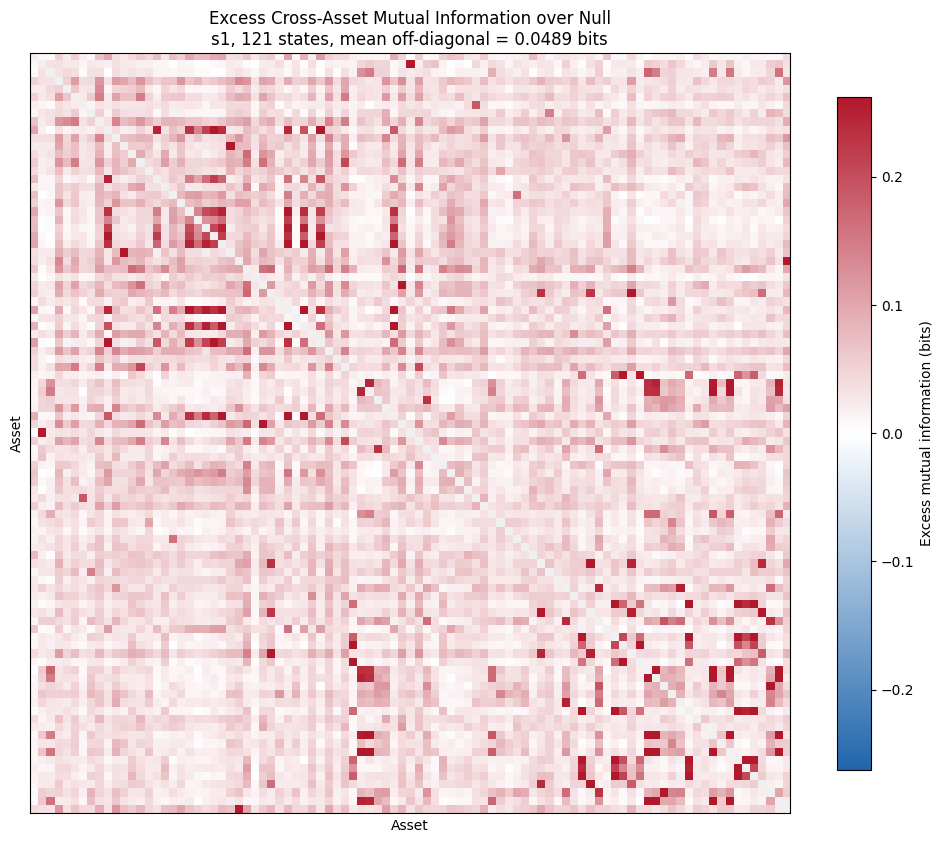

In [14]:
figure, axis = (
    plot_cross_asset_mi_heatmap(
        s1_cross_asset_mi,
        show_asset_labels=False
    )
)

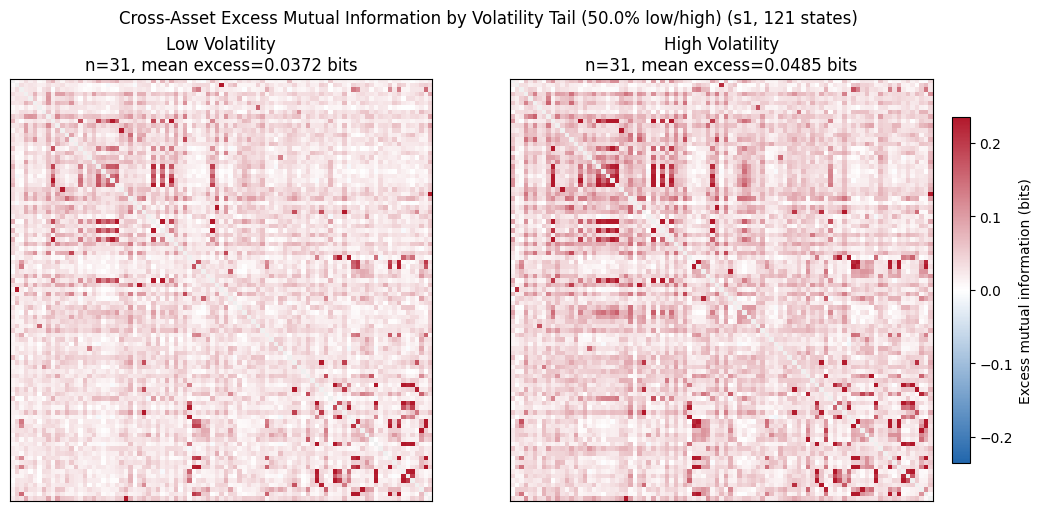

In [15]:
figure, axes = (
    plot_cross_asset_mi_regime_heatmaps(
        s1_cross_asset_mi,
    )
)

## Cross-asset mutual information

### Objective

The previous analysis measured temporal dependence within each asset:

$$
I(S_t^a;S_{t+h}^a).
$$

This section instead measures dependence **between assets at the same minute**:

$$
I(S_t^a;S_t^b).
$$

The question is:

> If the coarse representation of asset $a$ is known at a particular minute, how much uncertainty does this remove about the contemporaneous coarse representation of asset $b$?

This analysis is intended to determine whether the discrete representation contains cross-asset structure that could potentially be exploited by a graph-based forecasting model.

It is important to distinguish this from prediction:

- it is **contemporaneous**, not lagged;
- it is **symmetric**, not directed;
- it is estimated descriptively on July–September;
- it does not show that asset $a$ predicts the future of asset $b$;
- it does not show that asset $a$ adds information beyond asset $b$'s own history.

It therefore provides motivation for cross-asset modelling, but does not define the graph that the final model should learn.

---

## 1. Coarsening the representation space

The original `s1` codebook contains:

$$
1024
$$

possible IDs.

Estimating a separate $1024\times1024$ joint distribution for every pair of assets would be extremely sparse. The analysis therefore retains the:

$$
120
$$

most frequent coarse IDs in the complete July–September period and maps every remaining ID into a single **Other** category.

The resulting state space has:

$$
K=120+1=121
$$

states.

Let $m(\cdot)$ denote this mapping. The coarsened representation is:

$$
\widetilde S_{d,t,a}
=
m(S_{d,t,a})
\in
\{0,\ldots,120\}.
$$

The same mapping is used for:

- every asset;
- the overall analysis;
- the low-volatility analysis;
- the high-volatility analysis.

This ensures that the resulting matrices are comparable.

The coarsening is fitted on the same validation period being analysed. The analysis is therefore descriptive rather than out of sample.

---

## 2. Aligned cross-asset observations

For a pair of assets $a$ and $b$, observations are aligned by:

- trading session $d$;
- intraday bar $t$.

The observed pairs are:

$$
\left(
\widetilde S_{d,t,a},
\widetilde S_{d,t,b}
\right).
$$

Only the 331 bars per session with valid 60-minute causal contexts are used.

For the overall analysis, each asset pair therefore has:

$$
63\times331
=
20{,}853
$$

aligned observations.

There are 93 assets, giving:

$$
\binom{93}{2}
=
4{,}278
$$

unique unordered asset pairs.

A separate pairwise mutual-information value is calculated for each of these 4,278 pairs.

---

## 3. Observed cross-asset mutual information

For assets $a$ and $b$, define the empirical joint probability:

$$
\widehat p_{ab}(i,j)
=
\frac{1}{M}
\sum_{d,t}
\mathbf{1}
\left[
\widetilde S_{d,t,a}=i,
\widetilde S_{d,t,b}=j
\right],
$$

where $M$ is the number of aligned observations.

The corresponding marginal probabilities are:

$$
\widehat p_a(i)
=
\sum_j\widehat p_{ab}(i,j),
$$

$$
\widehat p_b(j)
=
\sum_i\widehat p_{ab}(i,j).
$$

The plug-in mutual-information estimate is:

$$
\widehat I_{\mathrm{obs}}(a,b)
=
\sum_{i,j:\widehat p_{ab}(i,j)>0}
\widehat p_{ab}(i,j)
\log_2
\left(
\frac{
\widehat p_{ab}(i,j)
}{
\widehat p_a(i)\widehat p_b(j)
}
\right).
$$

Equivalently:

$$
I(S^a;S^b)
=
H(S^b)-H(S^b\mid S^a).
$$

### Intuitive interpretation

Mutual information measures the average reduction in uncertainty about one asset after observing the other.

- $I=0$: the two representations are statistically independent;
- larger $I$: knowing one representation removes more uncertainty about the other;
- mutual information is measured in bits.

For example, an MI of $0.2$ bits corresponds to an effective uncertainty reduction of approximately:

$$
1-2^{-0.2}
\approx12.9\%.
$$

This does not mean 20% accuracy or a 20% probability of predicting the correct ID. It is an information-theoretic reduction in uncertainty.

Mutual information is symmetric:

$$
I(S^a;S^b)
=
I(S^b;S^a).
$$

The resulting matrix is therefore symmetric and cannot determine whether an edge should be interpreted as:

$$
a\rightarrow b
$$

or:

$$
b\rightarrow a.
$$

---

## 4. Why a permutation null is required

The plug-in mutual-information estimator is positively biased when the joint frequency table is large relative to the number of observations.

With 121 states, every asset pair has:

$$
121^2
=
14{,}641
$$

possible joint cells.

The overall analysis has only:

$$
20{,}853
$$

observations per pair.

The volatility subsets have only:

$$
31\times331
=
10{,}261
$$

observations per pair, fewer than the number of possible joint cells.

Consequently, many cells are empty or contain very few observations. Even statistically independent series can therefore produce a positive plug-in MI estimate.

A permutation null is used to estimate this finite-sample background.

---

## 5. Session-shuffled null distribution

For each null permutation $r$:

1. asset $a$ remains in its original session order;
2. the session order for asset $b$ is randomly permuted;
3. every complete intraday sequence is kept intact;
4. minute-of-day alignment is preserved;
5. mutual information is recalculated.

The null comparison is therefore approximately:

$$
I
\left(
\widetilde S^a_{d,t};
\widetilde S^b_{\pi_r(d),t}
\right),
$$

where $\pi_r(d)$ is a random permutation of the session index.

This procedure preserves:

- each asset's marginal representation distribution;
- the complete within-session representation sequence;
- within-session temporal dependence;
- systematic minute-of-day patterns.

It breaks:

- the actual same-date alignment between the two assets.

The analysis uses:

$$
R=20
$$

null permutations.

For each pair:

$$
\widehat I_{\mathrm{null}}(a,b)
=
\frac{1}{R}
\sum_{r=1}^{R}
\widehat I_{\mathrm{null}}^{(r)}(a,b).
$$

### Intuitive interpretation

The null MI answers:

> How much apparent pairwise dependence would be measured from finite-sample counting and persistent intraday patterns even after the actual same-day relationship between the assets has been broken?

It is not expected to be zero.

---

## 6. Excess cross-asset mutual information

The null-adjusted estimate is:

$$
\widehat I_{\mathrm{excess}}(a,b)
=
\widehat I_{\mathrm{obs}}(a,b)
-
\widehat I_{\mathrm{null}}(a,b).
$$

### Interpretation

- positive excess MI: observed same-day dependence is stronger than the permutation background;
- approximately zero: observed dependence is similar to the null expectation;
- negative excess MI: the observed plug-in MI is below the mean null estimate.

A negative excess value does not mean that true mutual information is negative. Mutual information itself is non-negative. It means only that the observed finite-sample estimate fell below the estimated null background.

Strictly, excess MI is a **null-adjusted effect size**, rather than mutual information in the formal entropy sense, because it may be negative.

---

## 7. Aggregation across asset pairs

The values in the summary tables are not one 93-dimensional multivariate MI calculation.

They are the mean of the 4,278 pairwise values:

$$
\overline I
=
\frac{1}{\binom{N}{2}}
\sum_{a<b}
I(a,b),
$$

where:

$$
N=93.
$$

Only the upper triangle is used, so each unordered pair is included once and the diagonal is excluded.

The table columns therefore mean:

### Observed Cross-Asset MI

$$
\overline I_{\mathrm{obs}}
=
\frac{1}{4{,}278}
\sum_{a<b}
\widehat I_{\mathrm{obs}}(a,b).
$$

This is the mean raw plug-in dependence between asset pairs.

### Null Cross-Asset MI

$$
\overline I_{\mathrm{null}}
=
\frac{1}{4{,}278}
\sum_{a<b}
\widehat I_{\mathrm{null}}(a,b).
$$

This is the mean dependence reproduced by the session-shuffled null.

### Excess Cross-Asset MI

$$
\overline I_{\mathrm{excess}}
=
\frac{1}{4{,}278}
\sum_{a<b}
\widehat I_{\mathrm{excess}}(a,b).
$$

This is the mean pairwise dependence remaining after null subtraction.

### Sessions

The number of trading sessions included in that calculation.

### States

The size of the coarsened representation space:

$$
121
=
120\text{ frequent IDs}
+
1\text{ Other state}.
$$

---

# Overall results

| Token stream | Observed MI | Null MI | Excess MI | Sessions | States |
|---|---:|---:|---:|---:|---:|
| Coarse (`s1`) | 0.532864 bits | 0.483941 bits | 0.048923 bits | 63 | 121 |

## Interpretation

The observed average cross-asset MI is:

$$
0.532864\text{ bits}.
$$

However, the session-shuffled null produces:

$$
0.483941\text{ bits}.
$$

The null therefore reproduces approximately:

$$
\frac{0.483941}{0.532864}
\approx90.8\%
$$

of the raw plug-in MI magnitude.

This demonstrates why the raw observed MI should not be interpreted directly. Most of its magnitude is attributable to the sparse finite-sample joint tables and the structure retained under the null.

After null subtraction, the mean excess is:

$$
0.048923\text{ bits per asset pair}.
$$

This is a modest but clearly positive average dependence estimate.

As a rough effect-size translation:

$$
1-2^{-0.048923}
\approx3.3\%.
$$

Thus, if the excess value is interpreted approximately as corrected information, observing one asset's coarse state reduces the effective uncertainty about another asset's contemporaneous coarse state by roughly 3.3% for the average pair.

This translation should be treated as intuition rather than an exact population quantity because:

- the value is averaged across heterogeneous asset pairs;
- it has been adjusted using a finite permutation null;
- it is not an unbiased population-MI estimate.

---

# Reading the overall heatmap

Each off-diagonal cell contains:

$$
\widehat I_{\mathrm{excess}}(a,b).
$$

The colour convention is:

- **red**: positive excess dependence;
- **white**: little difference from the null;
- **blue**: observed MI below the null mean;
- **grey diagonal**: self-pairs, which are excluded.

Assets are ordered by their marginal representation entropy. They are not ordered by:

- ticker;
- industry sector;
- return correlation;
- a learned clustering.

Therefore, visible blocks should not automatically be interpreted as sectors or economic communities.

The heatmap shows:

- broadly positive excess dependence across many pairs;
- substantial variation in the strength of dependence;
- stronger rows, columns and local blocks for some subsets of assets;
- relatively few strongly negative relationships.

The result is therefore not consistent with every asset pair being equally informative. Cross-asset dependence is heterogeneous.

However, the heatmap alone does not establish that the true forecasting graph is sparse. A formal sparse-graph claim would require, for example:

- pairwise uncertainty or permutation thresholds;
- multiple-comparison correction;
- a distribution of significant edges;
- or forecasting ablations showing that selecting a limited set of neighbours is beneficial.

The colour scale is clipped at the 99th percentile of absolute off-diagonal values. Extreme cells can therefore be saturated, and the end of the colour bar is not necessarily the true maximum pairwise value.

---

# Volatility-regime analysis

## Realised-volatility definition

For session $d$, asset $a$, and minute $t$, the one-minute log return is:

$$
r_{d,t,a}
=
\log
\left(
\frac{C_{d,t,a}}
{C_{d,t-1,a}}
\right).
$$

For each asset, within-session volatility is:

$$
\sigma_{d,a}
=
\sqrt{
\frac{1}{L}
\sum_{t=1}^{L}
\left(
r_{d,t,a}
-
\overline r_{d,a}
\right)^2
},
$$

where $L$ is the number of one-minute returns in the cleaned session.

The session-level realised-volatility score is the average across assets:

$$
RV_d
=
\frac{1}{N}
\sum_{a=1}^{N}
\sigma_{d,a}.
$$

The volatility score uses the complete cleaned Close series for each session. The MI calculation itself continues to use only the 331 bars with valid causal representations.

---

## Volatility groups

The sessions are ranked by $RV_d$.

With:

$$
\text{volatility tail fraction}
=
\frac{1}{2},
$$

the analysis uses:

- the lowest-volatility 31 sessions;
- the highest-volatility 31 sessions.

Because there are 63 sessions, the single median-ranked session is excluded so that the two groups are non-overlapping and equally sized.

The same:

- 121-state mapping;
- asset ordering;
- MI calculation;
- permutation-null procedure

is applied independently to each group.

---

## Volatility results

| Volatility group | Sessions | Mean realised volatility | Observed MI | Null MI | Excess MI |
|---|---:|---:|---:|---:|---:|
| Low volatility | 31 | 0.000552 | 0.845590 bits | 0.808402 bits | 0.037188 bits |
| High volatility | 31 | 0.000747 | 0.871659 bits | 0.823184 bits | 0.048475 bits |

The volatility scores correspond approximately to:

$$
0.000552\times10{,}000
=
5.52\text{ bps}
$$

and:

$$
0.000747\times10{,}000
=
7.47\text{ bps}
$$

of average within-session one-minute return volatility.

The high-volatility group is therefore approximately:

$$
\frac{0.000747}{0.000552}-1
\approx35.3\%
$$

more volatile than the low-volatility group.

---

## Why the raw regime MI values are larger

The observed and null MI values in both volatility groups are much larger than in the overall analysis.

This does not mean that splitting the sessions has suddenly created much stronger economic dependence.

Each regime contains only:

$$
31\times331
=
10{,}261
$$

aligned observations per asset pair, while each 121-state joint table has:

$$
14{,}641
$$

possible cells.

The regime joint distributions are therefore even sparser than the overall distribution. This increases the positive finite-sample bias of the raw plug-in estimator.

That is why both quantities rise:

$$
I_{\mathrm{observed}}
\quad\text{and}\quad
I_{\mathrm{null}}.
$$

The meaningful comparison is the excess:

$$
I_{\mathrm{observed}}
-
I_{\mathrm{null}},
$$

not the raw observed MI by itself.

---

## Cross-asset dependence is stronger during high volatility

The mean excess MI is:

$$
0.037188\text{ bits}
$$

during low-volatility sessions and:

$$
0.048475\text{ bits}
$$

during high-volatility sessions.

The absolute difference is:

$$
0.048475-0.037188
=
0.011287\text{ bits}.
$$

Relative to the low-volatility estimate, the high-volatility excess is approximately:

$$
\frac{0.048475}{0.037188}-1
\approx30.4\%
$$

larger.

Because the two regime heatmaps share one colour scale, the greater concentration of darker red cells in the high-volatility panel can be interpreted directly as stronger pairwise excess dependence.

The result suggests:

> Coarse asset representations become more strongly coupled across the market during volatile sessions.

This is economically plausible: market-wide shocks and common risk factors are likely to affect more assets simultaneously during periods of greater volatility.

It also supports the hypothesis that one fixed graph may not fully describe cross-asset structure. The strength and pattern of relationships may vary with market conditions.

---

## Why the overall excess can exceed both subgroup estimates

The overall excess is:

$$
0.048923\text{ bits},
$$

which is slightly above the high-volatility value:

$$
0.048475\text{ bits}.
$$

This is not a contradiction.

Mutual information is nonlinear, so the MI of a pooled distribution is not generally equal to the weighted average of the subgroup MIs:

$$
I(X;Y)
\neq
\sum_r
P(R=r)
I(X;Y\mid R=r).
$$

When the representation distributions of many assets change together between low- and high-volatility conditions, pooling the regimes can introduce additional shared regime information:

$$
\text{asset }a\text{ state}
\rightarrow
\text{market regime}
\rightarrow
\text{asset }b\text{ state}.
$$

The overall null is also estimated separately from the two subgroup nulls.

Finally, the difference between the overall and high-volatility excess values is only:

$$
0.048923-0.048475
=
0.000448\text{ bits}.
$$

This is extremely small and could also reflect sampling or permutation Monte Carlo variation.

---

# What these results establish

The analysis provides evidence that:

1. the coarse representations contain genuine contemporaneous cross-asset dependence beyond the session-shuffled background;
2. dependence strength varies substantially across asset pairs;
3. average dependence is stronger during high-volatility sessions;
4. cross-asset structure is therefore potentially useful to a graph-based representation and forecasting model;
5. graph structure may need to adapt to the current market context rather than remain completely fixed.

---

# What these results do not establish

The analysis does not show:

### Direction

Because mutual information is symmetric:

$$
I(S^a;S^b)=I(S^b;S^a).
$$

It cannot identify whether information flows from $a$ to $b$ or from $b$ to $a$.

### Causality

A positive relationship may arise from:

- a common market factor;
- common sector exposure;
- simultaneous response to public information;
- indirect relationships through other assets.

### Future predictability

The analysis measures:

$$
I(S_t^a;S_t^b),
$$

not:

$$
I(S_t^a;S_{t+h}^b).
$$

It does not demonstrate that one asset improves prediction of another asset's future representation.

### Incremental value beyond the target's own history

It does not compare:

$$
P(S_{t+h}^b\mid S_{\leq t}^b)
$$

with:

$$
P(S_{t+h}^b\mid S_{\leq t}^b,S_{\leq t}^a).
$$

The final graph model must establish that cross-asset information adds value after the target's own temporal information has already been modelled.

### Statistical significance of individual cells

Only 20 null permutations are used, and the analysis reports no:

- confidence intervals;
- pairwise permutation $p$-values;
- multiple-testing correction.

Individual red cells should therefore be treated as exploratory dependence estimates rather than confirmed graph edges.

### Independence from the state-space choice

The magnitude of observed and null MI depends strongly on the number of retained states. Increasing `top_k_tokens` creates a larger and sparser joint table.

The present numerical results are specific to:

$$
120\text{ frequent IDs}
+
1\text{ Other state}.
$$

A smaller state space produces smaller raw observed and null estimates. Robust conclusions should focus on whether the qualitative pattern survives reasonable state-count choices.

---

# Overall conclusion

The complete tokenizer analysis gives the following picture:

1. **High reconstruction fidelity**  
   The coarse and full representations preserve Close prices, one-minute returns, return volatility and Volume with relatively little distortion.

2. **A meaningful coarse-to-fine hierarchy**  
   The coarse representation captures most of the K-line structure, while the fine representation materially improves reconstruction.

3. **Non-collapsed but uneven codebook use**  
   The coarse codebook uses a broad range of states, while the fine representation is more concentrated and specialised.

4. **Strongly short-lived temporal predictability**  
   The current coarse state contains substantial information about the one-minute-ahead state, a smaller amount at five minutes, and little reliable first-order information beyond approximately 15–30 minutes.

5. **Modest but non-zero cross-asset dependence**  
   After accounting for the permutation-null background, contemporaneous coarse representations retain positive pairwise dependence.

6. **Market-state variation**  
   Cross-asset excess MI is approximately 30% larger during the high-volatility half of sessions than during the low-volatility half.

Together, these results motivate the final architecture:

- a compact temporal module should focus on the strong short-range structure;
- cross-asset message passing may provide information unavailable to a purely per-asset model;
- the graph should be selective because pairwise dependence is heterogeneous;
- an input-conditioned graph is worth testing because dependence strengthens and changes with market conditions.

The MI analysis does not prove that a dynamic graph will improve forecasting. That claim must be established through controlled model ablations comparing:

- no graph;
- a fixed correlation graph;
- a learned static graph;
- a learned static-plus-dynamic graph.

The purpose of this section is narrower: it shows that the representation contains both temporal and cross-asset structure for those models to attempt to exploit.

## Coarse-token vocabulary reduction by top-\(K\) retention and causal LOCF

This section measures the reconstruction ceiling of a smaller coarse-token
space without retraining the tokenizer.

For each candidate \(K\):

1. rank original `s1` IDs using January–June training frequency only;
2. retain the top \(K\) real Kronos IDs;
3. replace every discarded validation token with the most recent earlier
   retained token for that asset;
4. carry that LOCF state continuously across bars, sessions and the
   January–June to July–September boundary;
5. use the least frequent retained token only as an emergency fallback when
   no retained historical token exists;
6. decode with the frozen genuine coarse decoder using each rolling context's
   original mean and standard deviation;
7. compare the reconstruction with the unmodified continuous validation data.

The cell reuses the encoded and decoded variant files already present in
`REMAP_TEMP_DIR`. A missing \(K\) is generated and saved automatically.
`K=1024` reuses the existing `Coarse (s1)` baseline row and is never decoded
again.

These temporary files are reconstruction-analysis artefacts. They are not the
compact origin-aligned caches used to train the forecasting model.

In [16]:
# Candidate retained coarse-token vocabulary sizes.
# Existing encoded/decoded files are loaded; only missing variants are built.
K_VALUES = [
    1024,
    50,
    100,
    150,
    200,
    250,
]

s1_topk_locf_reconstruction = (
    compute_s1_topk_locf_reconstruction_sweep(
        training_encoded=encoded_kronos_train,
        validation_encoded=encoded_kronos_val,
        validation_split=kronos_val,
        validation_decoded=decoded_kronos_val,
        baseline_reconstruction_metrics=reconstruction_metrics,
        k_values=K_VALUES,
        output_dir=REMAP_TEMP_DIR,
        tokenizer_config=config,
        window_batch_size=WINDOW_BATCH_SIZE,
        series_batch_size=SERIES_BATCH_SIZE,
        reuse_existing=True,
        show_progress=True,
    )
)

display(
    style_s1_topk_locf_reconstruction_table(
        s1_topk_locf_reconstruction
    )
)

print(
    "Remapping reconstruction directory:",
    REMAP_TEMP_DIR,
)


k=50: loaded existing encoded and decoded variants; validation coverage=67.12%; context kept=72.81%; elapsed=0.04 min
k=100: loaded existing encoded and decoded variants; validation coverage=87.55%; context kept=87.34%; elapsed=0.03 min
k=150: loaded existing encoded and decoded variants; validation coverage=94.90%; context kept=92.90%; elapsed=0.04 min
k=200: loaded existing encoded and decoded variants; validation coverage=97.69%; context kept=95.33%; elapsed=0.04 min
k=250: loaded existing encoded and decoded variants; validation coverage=98.88%; context kept=97.87%; elapsed=0.04 min


,Codebook Retained (%),Train Token Coverage (%),Validation Token Coverage (%),Validation Context Kept (%),Close Median Error (bps),Close P95 Error (bps),Return MAE (bps),Return Correlation,Return Volatility Ratio,Log-Volume MAE,Invalid Candles (%)
Retained s1 Tokens (k),,,,,,,,,,,
1024,100.00,100.00,100.00,100.00,0.896287,3.756897,1.660665,0.878756,0.972224,0.263228,11.110286
50,4.88,66.58,67.12,72.81,1.760223,11.994289,3.339160,0.438293,0.925787,0.601232,6.970865
100,9.77,87.50,87.55,87.34,1.167835,7.147705,2.479659,0.659086,0.944646,0.431144,7.849055
150,14.65,94.93,94.90,92.90,1.007529,5.062256,2.062398,0.763522,0.970643,0.365299,9.866144
200,19.53,97.70,97.69,95.33,0.957129,4.402418,1.891369,0.814411,0.975928,0.329250,9.947719
250,24.41,98.90,98.88,97.87,0.923332,4.061973,1.791709,0.836186,0.967024,0.284987,10.510336


Remapping reconstruction directory: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/final_model/tokens/tmp_s1_topk_global_history_locf_validation
